# Reproduce: When Does Spatial Structure Matter?

**A Task-Adaptive Spatial Gating Framework for Soccer Action Outcome Prediction**

This notebook reproduces the main numerical results of the paper from the released aggregated metric tables (`data/results_*.json`). The raw StatsBomb 360 event data are proprietary and not included; see [`data/DATA_AVAILABILITY.md`](../data/DATA_AVAILABILITY.md) for the licence and pipeline notes.

## What this notebook covers

1. **Main Table 5**: 10 models $\times$ 9 tasks AUC/MAE (single-task and U1 multi-task)
2. **Table 6 / Figure 3**: U1 task-level gate means and alignment with CNN marginal gains
3. **Table 7**: Cross-league (EPL $\leftrightarrow$ La Liga) bidirectional evaluation
4. **Five-step covariate shift diagnostic** (Tables S1, S5, S7): ECE anomaly, pair-of-seasons drift, relaxed-holdout recovery
5. **Player-level ranking (Table 9)**: top dribblers by quality residual
6. **xG auxiliary metrics (Table S9)**: $R^2$ and Pearson $\rho$ for the xG regression task
7. **Regenerating figures**: pointers to plotting scripts under `scripts/`

## Setup

Activate the conda environment (`environment.yml`) and launch this notebook from the repository root:

```bash
conda env create -f environment.yml
conda activate kronos
jupyter notebook notebooks/reproduce.ipynb
```

In [91]:
import json
from pathlib import Path
import pandas as pd

# Resolve project root relative to the notebook location.
ROOT = Path('..').resolve()
DATA = ROOT / 'data'
WEIGHTS = ROOT / 'weights'
FIGURES = ROOT / 'figures'

assert DATA.exists(), 'Expected data/ relative to the notebook (../data)'
print(f'data/    : {len(list(DATA.glob("*.json")))} JSON files, {len(list((DATA/"predictions").glob("*.npz")))} NPZ files')
print(f'weights/ : {len(list(WEIGHTS.glob("*.pt")))} model checkpoints')
print(f'figures/ : {len(list(FIGURES.glob("*.pdf")))} PDF + {len(list(FIGURES.glob("*.png")))} PNG')

data/    : 16 JSON files, 48 NPZ files
weights/ : 2 model checkpoints
figures/ : 16 PDF + 16 PNG


## 1. Main Table 5: 10 models $\times$ 9 tasks

Binary tasks report AUC; the xG regression task reports MAE.

In [92]:
rows = json.loads((DATA / 'results_all.json').read_text())
print(f'Number of (task, model) entries in results_all.json: {len(rows)}')

TASKS = ['pass', 'dribble', 'ball_receipt', 'shot', 'duel',
         'interception', 'ball_recovery', 'pressure', 'xg']
MODELS = ['L1_LR_Event', 'L2_LR_360', 'B1_XGB_Event', 'B2_XGB_360',
          'M1_MLP_Event', 'M2_MLP_360', 'M3_CNN_Event', 'M4_CNN_Full',
          'G1_Gating', 'U1_Unified']

# Build a 9-row x 10-column table; AUC for binary tasks, MAE for xG.
table5 = pd.DataFrame(index=TASKS, columns=MODELS, dtype=float)
for r in rows:
    metric = r.get('test_mae') if r['task'] == 'xg' else r.get('test_auc')
    if r['task'] in TASKS and r['model'] in MODELS and metric is not None:
        table5.loc[r['task'], r['model']] = metric
table5.round(3)

Number of (task, model) entries in results_all.json: 90


,L1_LR_Event,L2_LR_360,B1_XGB_Event,B2_XGB_360,M1_MLP_Event,M2_MLP_360,M3_CNN_Event,M4_CNN_Full,G1_Gating,U1_Unified
pass,0.894,0.911,0.925,0.941,0.918,0.935,0.928,0.936,0.938,0.928
dribble,0.604,0.708,0.594,0.649,0.607,0.647,0.678,0.754,0.747,0.737
ball_receipt,0.729,0.881,0.742,0.892,0.738,0.888,0.906,0.949,0.950,0.937
shot,0.747,0.770,0.743,0.743,0.746,0.762,0.746,0.757,0.761,0.847
duel,0.599,0.620,0.669,0.709,0.669,0.678,0.643,0.619,0.594,0.583
interception,0.618,0.623,0.606,0.617,0.616,0.623,0.623,0.633,0.633,0.631
ball_recovery,0.535,0.685,0.536,0.693,0.537,0.693,0.647,0.704,0.706,0.704
pressure,0.532,0.589,0.556,0.627,0.552,0.628,0.649,0.656,0.633,0.644
xg,0.057,0.058,0.038,0.034,0.034,0.030,0.029,0.028,0.026,0.030


Verification against the published numbers in Section 5.1 of the main paper:

- Dribble M4 $-$ M2 = +0.107 AUC gain (paper abstract)
- U1 mean across 8 binary tasks vs Oracle: gap should be $\approx 0.024$

In [93]:
binary_tasks = [t for t in TASKS if t != 'xg']

dribble_delta = table5.loc['dribble', 'M4_CNN_Full'] - table5.loc['dribble', 'M2_MLP_360']
print(f'Dribble M4 - M2 = {dribble_delta:+.3f} AUC   (paper: +0.107)')

u1_mean = table5.loc[binary_tasks, 'U1_Unified'].mean()
oracle_mean = table5.loc[binary_tasks].max(axis=1).mean()
print(f'U1 mean    = {u1_mean:.3f}')
print(f'Oracle     = {oracle_mean:.3f}   (per-task best across all 10 models, including U1)')
print(f'Gap        = {oracle_mean - u1_mean:.3f}   (paper: 0.024)')

Dribble M4 - M2 = +0.107 AUC   (paper: +0.107)
U1 mean    = 0.751
Oracle     = 0.775   (per-task best across all 10 models, including U1)
Gap        = 0.023   (paper: 0.024)


## 2. Table 6 / Figure 3: U1 task-level gate means

U1 (Unified multi-task) records a per-event gate vector $g_i \in [0,1]^{64}$ that controls the spatial-versus-event-branch weighting. The paper reports $\bar{g}^{(a)}$, the per-task mean of the per-event scalar gate. A higher $\bar{g}^{(a)}$ indicates U1 assigns more weight to the spatial branch for task $a$.

In [94]:
u1_rows = [r for r in rows if r['model'] == 'U1_Unified']
table6 = pd.DataFrame([
    {'task': r['task'],
     'gate_mean': r.get('gate_mean'),
     'gate_std' : r.get('gate_std')}
    for r in u1_rows
]).set_index('task').loc[TASKS].round(3)
table6

,gate_mean,gate_std
task,,
pass,0.270,0.345
dribble,0.440,0.380
ball_receipt,0.413,0.384
shot,0.367,0.385
duel,0.424,0.403
interception,0.328,0.398
ball_recovery,0.231,0.315
pressure,0.295,0.379
xg,0.364,0.391


## 3. Table 7: Cross-league bidirectional evaluation

The cross-league setup trains on all three seasons of one league and tests on all three seasons of the other, in both directions (EPL $\to$ La Liga and La Liga $\to$ EPL).

The paper claim is that for any (task, model) cell, the bidirectional AUC difference is small (within 0.017), supporting league-direction stability of the spatial-gain pattern.

Note: L1 / L2 / B2 cells come from `results_cross_league_8tasks.json` (2-channel pipeline; these models do not use SoccerMap channels), while M4 and G1 cells come from `results_cross_league_8tasks_7ch.json` (7-channel run, consistent with the strict main benchmark). The Table 7 caption discloses this split.

In [95]:
cl_2ch = json.loads((DATA / 'results_cross_league_8tasks.json').read_text())
cl_7ch = json.loads((DATA / 'results_cross_league_8tasks_7ch.json').read_text())

# Compute the maximum bidirectional gap across all (task, model) cells.
def collect(rows, model_set):
    by_dir = {}
    for r in rows:
        if r['model'] not in model_set:
            continue
        key = (r['task'], r['model'])
        by_dir.setdefault(key, {})[r['experiment']] = r['test_auc']
    return by_dir

by_dir = {}
by_dir.update(collect(cl_2ch, {'L1_LR_Event', 'L2_LR_360', 'B2_XGB_360'}))
by_dir.update(collect(cl_7ch, {'M4_CNN_Full', 'G1_Gating'}))

gaps = []
for (task, model), dirs in by_dir.items():
    if len(dirs) == 2:
        gap = abs(list(dirs.values())[0] - list(dirs.values())[1])
        gaps.append((task, model, gap))

max_gap = max(gaps, key=lambda x: x[2])
print(f'Bidirectional cells evaluated: {len(gaps)}')
print(f'Maximum |EPL->LaLiga - LaLiga->EPL| = {max_gap[2]:.4f}  on {max_gap[0]} x {max_gap[1]}')
print(f'Paper claim (Section 5.3): maximum gap = 0.017 (overall), 0.016 for M4/G1')

Bidirectional cells evaluated: 24
Maximum |EPL->LaLiga - LaLiga->EPL| = 0.0170  on ball_recovery x L1_LR_Event
Paper claim (Section 5.3): maximum gap = 0.017 (overall), 0.016 for M4/G1


## 4. Five-Step Covariate Shift Diagnostic

Main paper Section 5.4 reports that the CNN models (M4, G1) on Dribble and Duel exhibit severe calibration degradation under the strict 24/25 holdout, while the architecture itself is intact; the degradation is attributed to a distribution shift in StatsBomb 360 input features at the 23/24 to 24/25 boundary.

### Step 1: ECE anomaly (Table S1)

In [96]:
cal = json.loads((DATA / 'results_calibration.json').read_text())
cal_df = pd.DataFrame(cal)

ece_table = cal_df.pivot_table(
    index='task', columns='model', values='ece', aggfunc='first')
task_order = ['pass', 'dribble', 'ball_receipt', 'shot', 'duel',
              'interception', 'ball_recovery', 'pressure']
model_order = ['Majority', 'L1_LR_Event', 'B2_XGB_360', 'M4_CNN_2ch', 'G1_Gating_2ch']
ece_table = ece_table.loc[[t for t in task_order if t in ece_table.index],
                          [m for m in model_order if m in ece_table.columns]]
print('ECE values above 0.10 (the severe-miscalibration threshold):')
print((ece_table > 0.10).any(axis=1))
ece_table.round(3)

ECE values above 0.10 (the severe-miscalibration threshold):
task
pass             False
dribble           True
ball_receipt     False
shot             False
duel              True
interception     False
ball_recovery    False
pressure         False
dtype: bool


model,Majority,L1_LR_Event,B2_XGB_360,M4_CNN_2ch,G1_Gating_2ch
task,,,,,
pass,0.013,0.019,0.005,0.016,0.015
dribble,0.008,0.016,0.102,0.272,0.378
ball_receipt,0.054,0.046,0.021,0.047,0.050
shot,0.051,0.045,0.040,0.040,0.023
duel,0.021,0.039,0.026,0.198,0.217
interception,0.011,0.032,0.029,0.019,0.037
ball_recovery,0.002,0.002,0.003,0.005,0.023
pressure,0.052,0.052,0.054,0.063,0.047


### Step 4: Pair-of-seasons drift on `sb_num_defenders_on_goal_side` (Table S5)

In [97]:
pairs = json.loads((DATA / 'results_season_pairs.json').read_text())

# Drill down to the Dribble task, feature sb_num_defenders_on_goal_side
feat = 'sb_num_defenders_on_goal_side'
rows_s5 = pairs['tasks']['dribble']['per_feature'][feat]
table_s5 = pd.DataFrame(rows_s5).T[['mean_a', 'mean_b', 'delta_over_std']].round(3)
table_s5.index.name = 'season pair'
table_s5

,mean_a,mean_b,delta_over_std
season pair,,,
22/23 -> 23/24,4.636,4.659,0.011
23/24 -> 24/25,4.659,3.975,-0.317
22/23 -> 24/25,4.636,3.975,-0.306


### Step 5: Relaxed holdout recovery (Table S7, ECE column)

In [98]:
import numpy as np
relaxed = json.loads((DATA / 'results_relaxed_holdout.json').read_text())
temp = json.loads((DATA / 'results_temperature.json').read_text())

# Strict ECE comes from results_temperature.json `before.ece`;
# Relaxed ECE comes from results_relaxed_holdout.json `test.ece`.
strict = {(r['task'], r['model']): r['before']['ece'] for r in temp}
relax  = {(r['task'], r['model']): r['test']['ece']   for r in relaxed}

rows_s7 = []
for key in strict:
    s, r = strict[key], relax.get(key)
    if r is None:
        continue
    rows_s7.append({'task': key[0], 'model': key[1], 'strict_ECE': s,
                    'relaxed_ECE': r, 'recovery_x': s / r})
table_s7 = pd.DataFrame(rows_s7).round({'strict_ECE': 3, 'relaxed_ECE': 3, 'recovery_x': 2})
print('Recovery factor (strict / relaxed) range matches paper claim 2.7x - 6.2x:')
table_s7

Recovery factor (strict / relaxed) range matches paper claim 2.7x - 6.2x:


,task,model,strict_ECE,relaxed_ECE,recovery_x
0,dribble,M4_CNN_2ch,0.242,0.089,2.72
1,dribble,G1_Gating_2ch,0.280,0.099,2.84
2,duel,M4_CNN_2ch,0.218,0.045,4.83
3,duel,G1_Gating_2ch,0.235,0.038,6.22


## 5. Player-level ranking: top dribblers by quality residual (Table 9)

Quality residual = actual success rate $-$ model-predicted success rate, computed per player on the relaxed-holdout 24/25 test set. Players with at least 20 dribbles qualify.

In [99]:
ranking = json.loads((DATA / 'results_dribble_ranking.json').read_text())
top10 = pd.DataFrame(ranking['M4_CNN_2ch']['top20'][:10])[
    ['player_name', 'team_name', 'n', 'actual_rate', 'predicted_rate', 'quality']
].round(3)
top10

,player_name,team_name,n,actual_rate,predicted_rate,quality
0,Adama Traoré Diarra,Fulham,23,0.696,0.568,0.128
1,Sávio Moreira de Oliveira,Manchester City,23,0.739,0.653,0.086
2,Jeremy Doku,Manchester City,29,0.655,0.580,0.075
3,Jadon Sancho,Chelsea,33,0.515,0.450,0.066
4,Ryan Gravenberch,Liverpool,21,0.524,0.468,0.056
5,Alex Iwobi,Fulham,23,0.739,0.685,0.055
6,Chidera Ejuke,Sevilla,22,0.636,0.588,0.049
7,Kaoru Mitoma,Brighton & Hove Albion,25,0.360,0.318,0.042
8,Antoine Semenyo,AFC Bournemouth,25,0.680,0.642,0.038
9,Mohamed Salah,Liverpool,42,0.405,0.391,0.014


## 6. xG auxiliary metrics (Table S9)

Main paper reports MAE for xG; this auxiliary table adds $R^2$ and Pearson $\rho$ against the StatsBomb `shot_statsbomb_xg` field.

In [100]:
xg = json.loads((DATA / 'results_xg_pearson.json').read_text())
table_s9 = pd.DataFrame(xg['models'])[['model', 'mae', 'r2', 'pearson']]
table_s9.columns = ['Model', 'MAE', 'R^2', 'rho']
table_s9.round({'MAE': 4, 'R^2': 3, 'rho': 3})

,Model,MAE,R^2,rho
0,L1_LR_Event,0.0527,0.357,0.609
1,L2_LR_360,0.0509,0.456,0.688
2,B1_XGB_Event,0.0353,0.602,0.780
3,B2_XGB_360,0.0251,0.785,0.887
4,M1_MLP_Event,0.0338,0.587,0.769
5,M2_MLP_360,0.0301,0.734,0.863
6,M3_CNN_Event,0.0292,0.725,0.854
7,M4_CNN_Full,0.0277,0.771,0.878
8,G1_Gating,0.0260,0.781,0.888
9,U1_Unified,0.0299,0.716,0.846


## 7. U1 training diagnostics and val-vs-test gap

U1 was trained for 30 epochs. The combined val AUC plateaus around epoch 7 and the best-state weight-save policy captures the global peak at epoch 24. The cells below verify training health (no NaN, no loss spike, no inverted labels), report each task's plateau epoch, and compute the val-vs-test AUC gap as a third independent ranking alongside the ECE-gap and mean-prediction-drift rankings reported in Section 6 of the main paper.


In [101]:
import matplotlib.pyplot as plt

hist = json.loads((DATA / 'u1_epoch_history.json').read_text())
train_loss = np.array(hist['train_loss_per_epoch'])

print(f"epochs           : {len(train_loss)}")
print(f"n_train_samples  : {hist['n_train_samples']:,}")
print(f"n_val_samples    : {hist['n_val_samples']:,}")
print(f"best_epoch       : {hist['best_epoch']}")
print(f"best_val_auc     : {hist['best_val_auc_combined']:.4f}")

checks = {
    'no_nan_inf'           : not (np.any(np.isnan(train_loss)) or np.any(np.isinf(train_loss))),
    'no_loss_spike_0.10'   : not np.any(np.diff(train_loss) > 0.10),
    'all_tasks_above_0.5'  : all(np.nanmax(np.array(v, dtype=float)) > 0.5
                                 for tn, v in hist['val_auc_per_task_per_epoch'].items()
                                 if tn != 'xg'),
}
for k, v in checks.items():
    print(f"  {k:24s} {'PASS' if v else 'FAIL'}")


epochs           : 30
n_train_samples  : 401,712
n_val_samples    : 101,124
best_epoch       : 24
best_val_auc     : 0.9626
  no_nan_inf               PASS
  no_loss_spike_0.10       PASS
  all_tasks_above_0.5      PASS


### Training-process figure

The 4-panel diagnostic below was rendered from `u1_epoch_history.json` (written by `scripts/training/train_unified.py` during the actual 30-epoch training run). Panel (a) shows train loss and combined val AUC on dual axes with the best-state (ep 24) and plateau (ep 2) epochs marked; (b) the xG-regression val MAE; (c) per-task val-AUC noise floor ($\sigma$ over the last 10 epochs); (d) per-task val AUC vs epoch for the eight binary tasks, ordered easy-to-hard by max AUC.

![Training convergence](training_convergence.png)


### Per-task plateau epoch (val AUC reaches 99% of its peak)

Easy tasks (Ball Receipt, Dribble) saturate within 1-2 epochs; hard tasks (Pressure, Interception) require 14-22 epochs. The combined-AUC plateau at epoch 7 already captures all easy-task gains, while the additional epochs 8-30 mostly serve the hard tasks.


In [102]:
def detect_plateau(arr, threshold=0.99):
    a = np.asarray(arr, dtype=float)
    if (~np.isnan(a)).sum() < 3:
        return None
    target = threshold * np.nanmax(a)
    for i, v in enumerate(a):
        if not np.isnan(v) and v >= target:
            return i + 1
    return None

plateau_rows = []
for tn, aucs in hist['val_auc_per_task_per_epoch'].items():
    if tn == 'xg':
        continue
    a = np.array(aucs, dtype=float)
    valid = a[~np.isnan(a)]
    plateau_rows.append({
        'task'         : tn,
        'best_val_auc' : float(np.nanmax(a)),
        'final_val_auc': float(valid[-1]),
        'sigma_last10' : float(np.std(valid[-10:])),
        'plateau_ep'   : detect_plateau(a, 0.99),
    })
pd.DataFrame(plateau_rows).sort_values('best_val_auc', ascending=False).round(4)


,task,best_val_auc,final_val_auc,sigma_last10,plateau_ep
2,ball_receipt,0.9936,0.9853,0.0028,2
1,dribble,0.9926,0.9887,0.0014,1
0,pass,0.9206,0.9179,0.0010,7
4,duel,0.8968,0.8899,0.0027,4
3,shot,0.8409,0.8364,0.0027,12
6,ball_recovery,0.7123,0.7010,0.0041,4
7,pressure,0.6683,0.6527,0.0072,22
5,interception,0.6296,0.6165,0.0057,14


### Val-vs-test AUC gap per task

Val comes from the in-season 80/20 split of the 22/23 and 23/24 seasons; test comes from the held-out 24/25 season. We pair each task's val best from the epoch history with the corresponding U1_Unified test AUC:


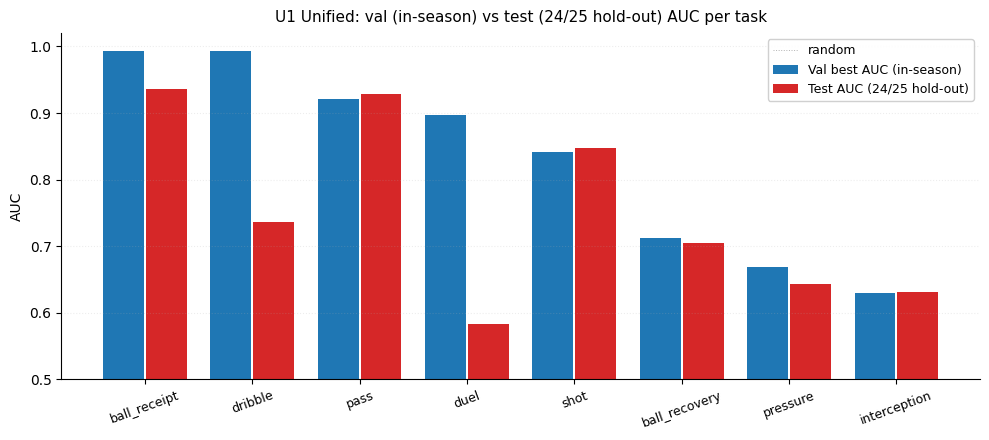

,task,val_best_AUC,test_AUC,gap
4,duel,0.8968,0.5827,0.3141
1,dribble,0.9926,0.7368,0.2558
2,ball_receipt,0.9936,0.9368,0.0569
7,pressure,0.6683,0.6438,0.0245
6,ball_recovery,0.7123,0.7042,0.0082
5,interception,0.6296,0.6312,-0.0016
3,shot,0.8409,0.8473,-0.0064
0,pass,0.9206,0.9281,-0.0075


In [103]:
val_best = {tn: float(np.nanmax(np.array(a, dtype=float)))
            for tn, a in hist['val_auc_per_task_per_epoch'].items()
            if tn != 'xg'}
test_u1 = {r['task']: r.get('test_auc') for r in rows
           if r.get('model') == 'U1_Unified' and r.get('task') in val_best}

gap_df = pd.DataFrame([{'task': tn,
                        'val_best_AUC': val_best[tn],
                        'test_AUC': test_u1[tn],
                        'gap': val_best[tn] - test_u1[tn]}
                       for tn in val_best if tn in test_u1]
                     ).sort_values('gap', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
df_show = gap_df.sort_values('val_best_AUC', ascending=False)
x = np.arange(len(df_show))
ax.bar(x - 0.20, df_show['val_best_AUC'], width=0.38, color='#1f77b4', label='Val best AUC (in-season)')
ax.bar(x + 0.20, df_show['test_AUC'],     width=0.38, color='#d62728', label='Test AUC (24/25 hold-out)')
for i, (_, r) in enumerate(df_show.iterrows()):
    if r['gap'] > 0.15:
        ax.annotate(f"-{r['gap']:.3f}", xy=(i + 0.20, r['test_AUC']),
                    xytext=(i + 0.20, r['test_AUC'] - 0.07),
                    ha='center', fontsize=8, color='#d62728', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(df_show['task'], rotation=20, fontsize=9)
ax.set_ylabel('AUC'); ax.set_ylim(0.5, 1.02)
ax.axhline(0.5, color='gray', linewidth=0.7, linestyle=':', alpha=0.6, label='random')
ax.grid(axis='y', alpha=0.22, linestyle=':')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', fontsize=9, framealpha=0.92)
ax.set_title('U1 Unified: val (in-season) vs test (24/25 hold-out) AUC per task', fontsize=11, pad=8)
plt.tight_layout(); plt.show()

gap_df.round(4)


Duel (gap +0.31) and Dribble (gap +0.26) lead by a large margin; the other six tasks all sit within |gap| < 0.06. Both Duel and Dribble also lead the ECE-gap and mean-prediction-drift rankings reported in Section 6 of the main paper, so three independent metrics (calibration, mean drift, generalisation gap) agree on the same two-task drift leader set.


## 8. Regenerating figures from the plotting scripts

Every figure in the paper can be regenerated from the cached metrics + prediction NPZ files in `data/`. Each plotting script writes its output to `figures/` (overwriting the released PDF/PNG).

An example: regenerate Figure 2 (the main results heatmap):

```bash
cd scripts/
PYTHONPATH=.. python plotting/plot_main_heatmap.py
# Output: ../figures/fig2.pdf (and .png)
```

Mapping of paper figures to scripts:

| Figure       | Script                                                  |
| ------------ | ------------------------------------------------------- |
| Fig. 1       | `plotting/plot_method_overview.py`                      |
| Fig. 2       | `plotting/plot_main_heatmap.py`                         |
| Fig. 3       | `plotting/plot_gate_vs_delta_auc.py`                    |
| Fig. 4       | `plotting/plot_fig5_diagnostic.py`                      |
| Fig. 5       | `plotting/player_dribble_ranking.py`                    |
| Fig. 6       | `plotting/plot_saliency_grid.py`                        |
| Fig. 7       | `plotting/compare_xpass_vs_sb.py`                       |
| Fig. 8       | `plotting/plot_u1_radar.py`                             |
| Fig. S1      | `supplementary_plots/plot_reliability_diagrams.py`      |
| Fig. S2      | `supplementary_plots/plot_strict_vs_relaxed.py`         |
| Fig. S3      | `supplementary_plots/analyze_within_2425_shift.py`      |
| Fig. S4      | `supplementary_plots/plot_failure_analysis.py`          |
| Fig. S5      | `supplementary_plots/plot_team_dribble_dist.py`         |
| Fig. S6      | `supplementary_plots/plot_what_if_simulation.py`        |
| Fig. S7      | `supplementary_plots/plot_player_case_study.py`         |

Some plotting scripts (Fig. 6 Grad-CAM, Fig. S4 / S6 / S7) additionally require the raw `data/cache/L1_events_v3.parquet` and `data/cache/action_soccermaps_*.npy` files, which are excluded from this release per the StatsBomb data licence. The other figures regenerate fully from the included aggregated JSON and clean prediction NPZ.

## 9. Loading the trained model weights

Two model checkpoints are released:

- `weights/dribble_cnn_weights.pt`: the 2-channel CNN concat-fusion model (M4) trained on the relaxed-holdout Dribble task. Used for Grad-CAM (Fig. 6) and the what-if simulation (Fig. S6).
- `weights/u1_weights.pt`: the multi-task unified model (U1) with task embedding $\mathbf{E} \in \mathbb{R}^{9 \times 16}$. Used for the radar profile (Fig. 8) and the per-task predictions in `data/predictions/u1_per_task.npz`.

Both checkpoints are PyTorch state dictionaries. They can be loaded with:

```python
import torch
sd = torch.load('weights/dribble_cnn_weights.pt', map_location='cpu')
print(sd.keys())
```

For inference, instantiate the matching model class from `scripts/training/train_all.py` (`CNNMLPModel(tab_dim=..., cnn_channels=2)` for `dribble_cnn_weights.pt`) or `scripts/training/train_unified.py` (`UnifiedGatingModel(...)` for `u1_weights.pt`) and call `.load_state_dict(sd)`.

In [104]:
import torch

for ckpt in ['dribble_cnn_weights.pt', 'u1_weights.pt']:
    sd = torch.load(WEIGHTS / ckpt, map_location='cpu')
    n_params = sum(t.numel() for t in sd.values())
    print(f'{ckpt}: {len(sd)} tensors, {n_params:,} parameters')

dribble_cnn_weights.pt: 22 tensors, 40,803 parameters
u1_weights.pt: 27 tensors, 54,547 parameters
